# Деревья решений и их внутренняя механика


### Цели работы
1.  Реализовать алгоритм построения дерева решений  с нуля.
2.  Исследовать Bias-Variance Tradeoff на примере гиперпараметра `max_depth`.
3.  Понять ограничения деревьев (экстраполяция).
4.  Научиться интерпретировать модель через `feature_importances_`.


In [12]:
from pyexpat import features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error

# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42
plt.style.use('ggplot')

## Реализация Дерева Решений

**Это задание повышенной сложности.** Необходимо реализовать алгоритм CART (Classification and Regression Trees) самостоятельно, заполнив пропуски в классах ниже

**Требования:**

1. Реализовать расчет Gini Impurity и MSE.
2. Реализовать поиск лучшего разбиения (`_best_split`).
3. Реализовать рекурсивное построение дерева (`_grow_tree`).
4. Реализовать проход по дереву для предсказания (`_traverse_tree`).

In [1]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

class MyBaseDecisionTree:
    def __init__(self, max_depth=100, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(np.array(X), np.array(y))

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._calculate_leaf_value(y)
            return Node(value=leaf_value)

        feat_idx, thresh = self._best_split(X, y, n_feats)

        if feat_idx is None:
            return Node(value=self._calculate_leaf_value(y))

        left_idxs, right_idxs = X[:, feat_idx] <= thresh, X[:, feat_idx] > thresh
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=feat_idx, threshold=thresh, left=left, right=right)

    def _best_split(self, X, y, n_feats):
        best_gain = 0
        split_idx, split_thresh = None, None

        inf = self._calculate_impurity(y)

        for j in range(len(X[0])):
            for t in np.unique(X[:, j])[:-1]:
                mask_l, mask_r = X[:, j] <= t, X[:, j] > t
                y_l, y_r = y[mask_l], y[mask_r]
                inf_l, inf_r = self._calculate_impurity(y_l), self._calculate_impurity(y_r)
                gain = inf - (len(y_l) * inf_l + len(y_r) * inf_r) / len(y)
                if best_gain < gain:
                    split_idx, split_thresh = j, t
                    best_gain = gain

        return split_idx, split_thresh

    def _calculate_leaf_value(self, y):
        raise NotImplementedError

    def _calculate_impurity(self, y):
        raise NotImplementedError

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in np.array(X)])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


In [2]:
# КЛАССИФИКАЦИЯ
class MyDecisionTreeClassifier(MyBaseDecisionTree):
    def _calculate_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return 1 - np.sum(p ** 2)

    def _calculate_leaf_value(self, y):
        # Самый частый класс
        counter = Counter(y)
        return counter.most_common(1)[0][0]


In [3]:
# РЕГРЕССИЯ
class MyDecisionTreeRegressor(MyBaseDecisionTree):
    def _calculate_impurity(self, y):
        return np.var(y)

    def _calculate_leaf_value(self, y):
        return np.mean(y)

## Самопроверка

In [26]:

print("Проверка Классификации")
X_test_cls, y_test_cls = make_moons(n_samples=100, noise=0.1, random_state=42)
my_clf = MyDecisionTreeClassifier(max_depth=3)
try:
    my_clf.fit(X_test_cls, y_test_cls)
    print("MyClassifier Accuracy:", accuracy_score(y_test_cls, my_clf.predict(X_test_cls)))
except Exception as e:
    print("Ошибка:", e)

print("=*50")
print("\nПроверка Регрессии ")
X_test_reg = np.array([[1], [2], [3], [4], [5]])
y_test_reg = np.array([1.1, 1.9, 3.1, 4.2, 4.8])
my_reg = MyDecisionTreeRegressor(max_depth=3)
try:
    my_reg.fit(X_test_reg, y_test_reg)
    print("MyRegressor MSE:", mean_squared_error(y_test_reg, my_reg.predict(X_test_reg)))
except Exception as e:
    print("Ошибка:", e)

Проверка Классификации
MyClassifier Accuracy: 0.93
=*50

Проверка Регрессии 
MyRegressor MSE: 0.0


## Поиск оптимальной глубины

Задача - найти ту глубину (`max_depth`), при которой модель работает лучше всего на новых данных, но еще не начала запоминать шум.

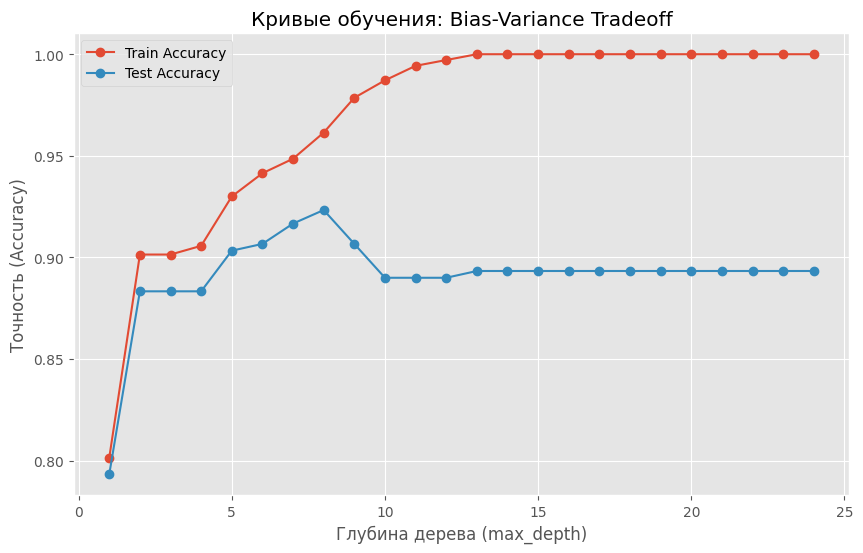

In [38]:
# 1. Генерация данных
X, y = make_moons(n_samples=1000, noise=0.3, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

train_scores = []
test_scores = []
depths = range(1, 25)

# 2. Цикл обучения
for depth in depths:
    # ВАШ КОД: Обучить DecisionTreeClassifier с max_depth=depth
    clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)

    # Сохраняем метрики
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# 3. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Глубина дерева (max_depth)')
plt.ylabel('Точность (Accuracy)')
plt.title('Кривые обучения: Bias-Variance Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

## Проблема экстраполяции

Деревья решений не умеют предсказывать значения за пределами обучающего диапазона, так как в листьях содержится константное значение (среднее)
Продемонстрируйте это

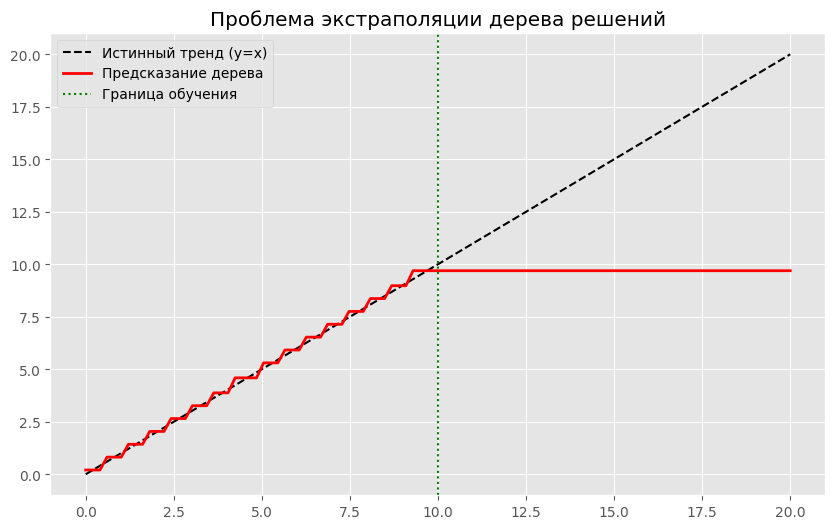

In [39]:
# Обучающие данные: Линия y = x от 0 до 10
X_train = np.linspace(0, 10, 50).reshape(-1, 1)
y_train = X_train.ravel()

# Тестовые данные: Линия от 0 до 20
X_test = np.linspace(0, 20, 100).reshape(-1, 1)
y_test_true = X_test.ravel()

# ВАШ КОД: Обучите DecisionTreeRegressor на X_train
reg = DecisionTreeRegressor(max_depth=8, min_samples_split=5)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_test_true, 'k--', label='Истинный тренд (y=x)')
plt.plot(X_test, y_pred, 'r', label='Предсказание дерева', linewidth=2)
plt.axvline(x=10, color='g', linestyle=':', label='Граница обучения')
plt.legend()
plt.title('Проблема экстраполяции дерева решений')
plt.show()

## Интерпретация модели

Используйте датасет Titanic для анализа важности признаков

1. Предобработайте данные (удалите NaN, закодируйте пол).
2. Обучите дерево.
3. Выведите топ-3 самых важных признака.

/var/folders/1c/t2y1wsfd6n764tx1jwkhq6l00000gn/T/ipykernel_8002/1013052174.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


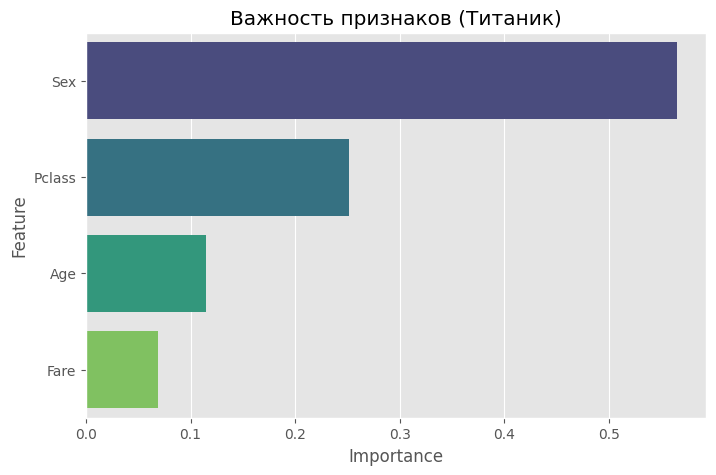

In [40]:
# Загрузка данных
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ВАШ КОД: Предобработка
# 1. Оставьте колонки ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
# 2. Удалите строки с NaN
# 3. Замените 'male'->0, 'female'->1

df_clean = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].dropna().copy()
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

X_titanic = df_clean.drop('Survived', axis=1)
y_titanic = df_clean['Survived']

# ВАШ КОД: Обучение DecisionTreeClassifier (max_depth=4)
clf_titanic = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
clf_titanic.fit(X_titanic, y_titanic)

# ВАШ КОД: Визуализация важности (sns.barplot)
importances = pd.DataFrame({
    'Feature': X_titanic.columns,
    'Importance': clf_titanic.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Важность признаков (Титаник)')
plt.show()

## Задание 4. Влияние регуляризации на границы

Исследуйте, как параметр `min_samples_leaf` влияет на сложность границы решений.
Обучите два дерева на датасете `make_moons`:
1. `min_samples_leaf=1` (стандартное переобучение)
2. `min_samples_leaf=20` (сглаживание)

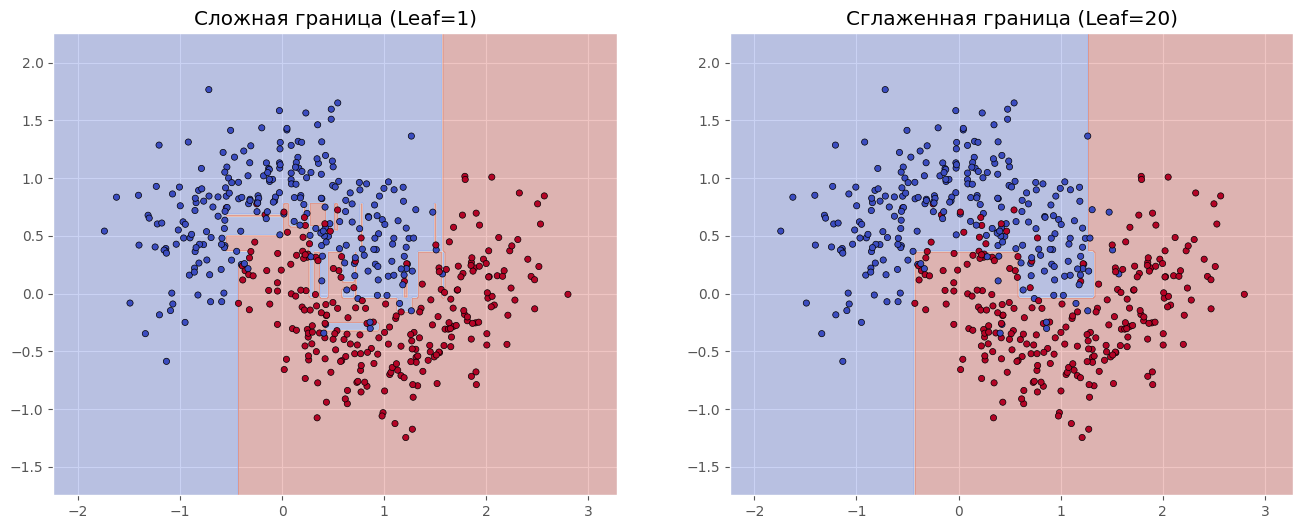

In [43]:
# Функция для отрисовки границ
def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=20)
    ax.set_title(title)

X, y = make_moons(n_samples=500, noise=0.3, random_state=RANDOM_STATE)

# ВАШ КОД: Обучение моделей
tree_complex = DecisionTreeClassifier(min_samples_leaf=1, random_state=RANDOM_STATE)
tree_smooth = DecisionTreeClassifier(min_samples_leaf=20, random_state=RANDOM_STATE)

tree_complex.fit(X, y)
tree_smooth.fit(X, y)

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
plot_boundary(tree_complex, X, y, ax[0], "Сложная граница (Leaf=1)")
plot_boundary(tree_smooth, X, y, ax[1], "Сглаженная граница (Leaf=20)")
plt.show()